# Regression Workshop: Predicting Fish Weight

**Time:** ~90 minutes

### The Big Picture
Today you'll use real fish market data to build a model that predicts how much a fish weighs, just from a couple of measurements you could take with a ruler. We'll do it in 6 steps:

1. Load & explore the data, and catch a data-entry mistake
2. Visualize how each measurement relates to weight
3. Quantify those relationships with correlation, and pick the best feature
4. Fit your first regression model: a straight line
5. **Curve it:** notice where the line falls short, and fix it with polynomial regression
6. **Capstone:** use your best model to predict new fish weights, and evaluate it honestly

Each question builds on the one before it, so try not to skip ahead. Raise your hand any time you get stuck!

### Before we start: get the data
Run the two cells below. The first loads the libraries you'll need. The second downloads the dataset (real fish market data, from Kaggle) straight into this folder — no account or manual download needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

print("Ready to go!")

Ready to go!


In [2]:
import urllib.request
import zipfile

url = "https://www.kaggle.com/api/v1/datasets/download/vipullrathod/fish-market"
urllib.request.urlretrieve(url, "fish-market.zip")

with zipfile.ZipFile("fish-market.zip") as z:
    z.extractall(".")

print("Downloaded Fish.csv")

Downloaded Fish.csv


---
## Question 1: Meet the Data

This dataset has 159 fish caught and measured at a fish market. For each fish we know its species and five body measurements (three different length measurements, height, and width), plus its weight — which is what we want to predict.

**Your tasks:**
1. Load `Fish.csv` into a DataFrame called `fish`.
2. Look at its shape and the first few rows.
3. Find out how many species are in the dataset, and how many fish of each.
4. Something is wrong with one row — one fish is listed as weighing 0 grams, which is impossible. Find that row, then remove it from the DataFrame and save the result as `fish_clean`.

Hint: look up `pandas.read_csv`, `.shape`, `.head()`, `.value_counts()`, and how to filter a DataFrame with a condition.

In [28]:
# TODO: load the data
fish = pd.read_csv("Fish.csv")

# TODO: look at shape and first few rows
print(fish.shape)
print(fish.head(3))

# TODO: how many fish of each species?
species_counts = fish["Species"].value_counts()

# TODO: find the fish with 0 weight
zero_weight_fish = fish[fish["Weight"]==0]

# TODO: remove it and save as fish_clean
fish_clean = fish[fish["Weight"]>0]

print("Species counts:\n", species_counts)
print("Zero-weight fish:\n", zero_weight_fish)
print("Cleaned shape:", fish_clean.shape)

(159, 7)
  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
Species counts:
 Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64
Zero-weight fish:
    Species  Weight  Length1  Length2  Length3  Height   Width
40   Roach     0.0     19.0     20.5     22.8  6.4752  3.3516
Cleaned shape: (158, 7)


**Check your work:** `fish.shape` should be `(159, 7)`. There are 7 species: Perch (56), Bream (35), Roach (20), Pike (17), Smelt (14), Parkki (11), Whitefish (6). The zero-weight fish is a **Roach**. After removing it, `fish_clean.shape` should be `(158, 7)`.

Use `fish_clean` (not `fish`) for the rest of the notebook.

---
## Question 2: Visualize the Relationships

Before fitting any model, always look at your data first. We have 5 candidate measurements to predict `Weight` from: `Length1`, `Length2`, `Length3`, `Height`, `Width`.

**Your tasks:**
1. Plot a histogram of `Weight`. Is its distribution symmetric, or skewed to one side?
2. Make a scatter plot of `Weight` (y-axis) against each of the 5 measurements (x-axis) — 5 scatter plots total. A grid of subplots works well, but one at a time is fine too.
3. In a short comment, note which feature(s) look most tightly (linearly) related to `Weight`, and which look noisiest.

Hint: look up `DataFrame.hist()` or `plt.hist()` for the histogram, `plt.scatter()` for the scatter plots, and `plt.subplots(nrows, ncols)` if you want a grid.

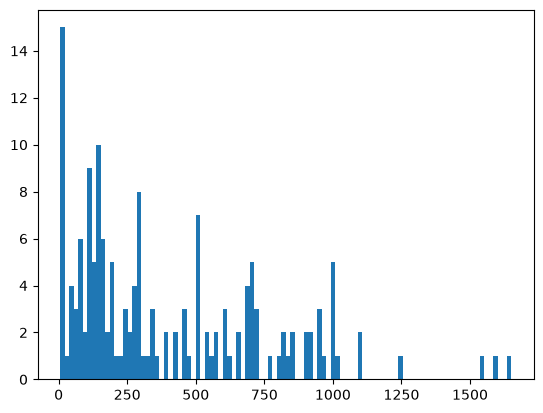

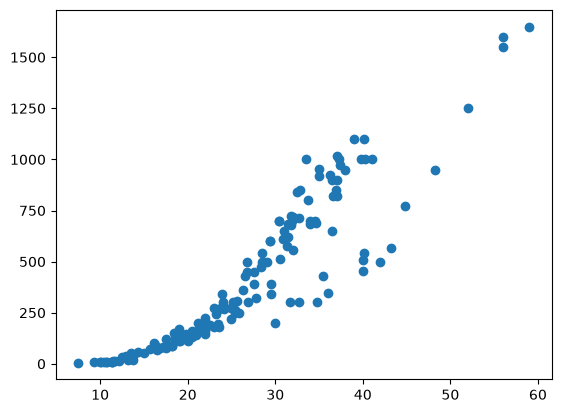

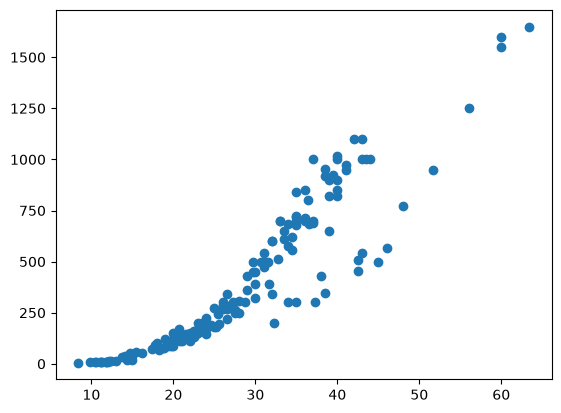

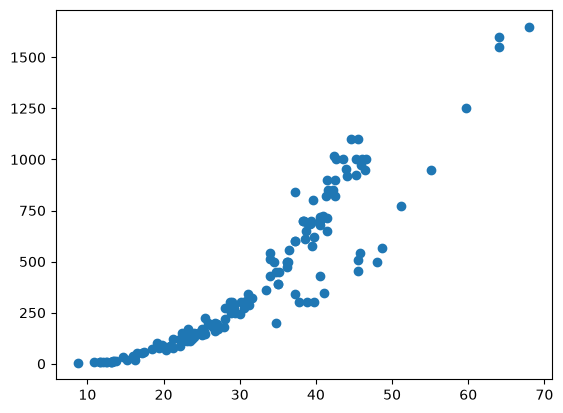

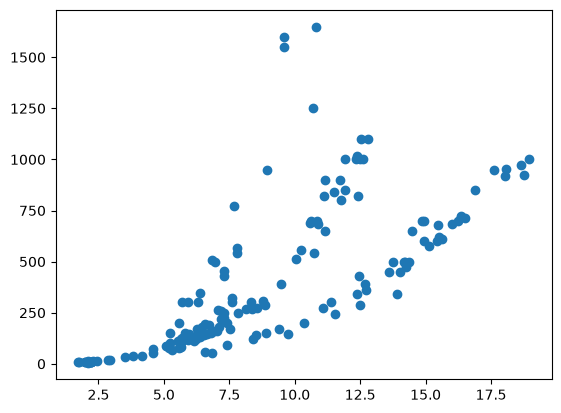

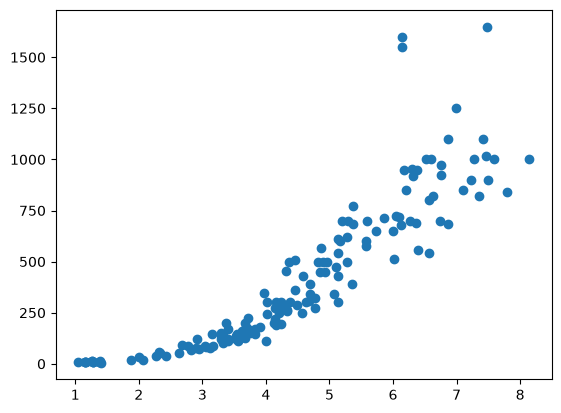

In [ ]:
# TODO: histogram of Weight

plt.hist(fish_clean["Weight"], bins=100)
plt.show()



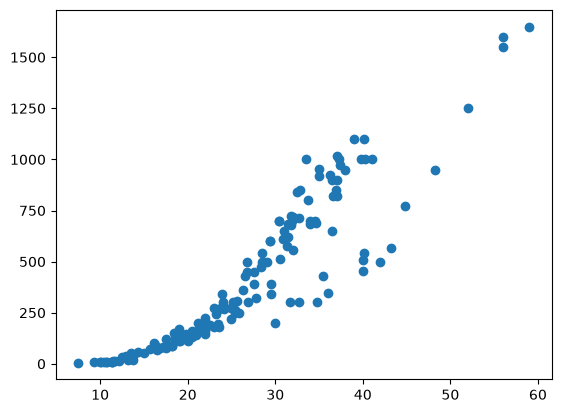

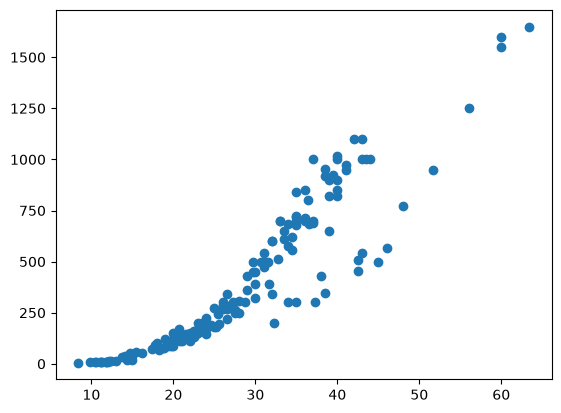

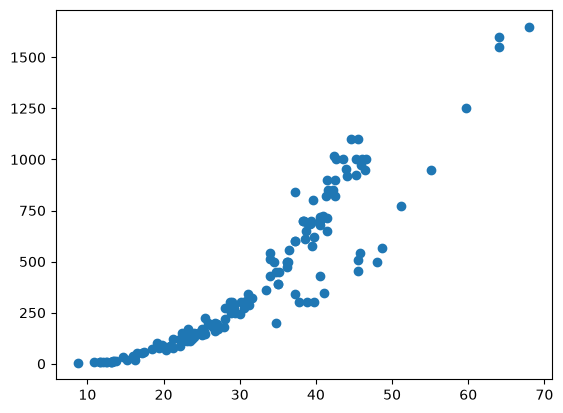

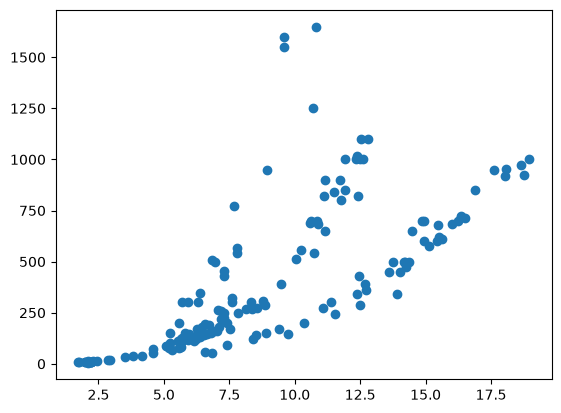

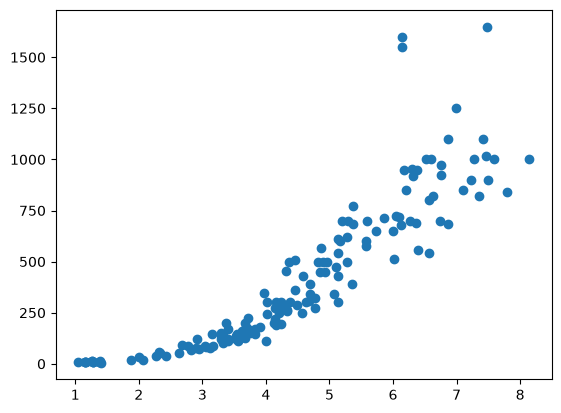

In [47]:
features = ["Length1", "Length2", "Length3", "Height", "Width"]

# TODO: scatter plot of Weight vs. each feature
plt.scatter(fish_clean["Length1"],fish_clean["Weight"])
plt.show()

plt.scatter(fish_clean["Length2"],fish_clean["Weight"])
plt.show()

plt.scatter(fish_clean["Length3"],fish_clean["Weight"])
plt.show()

plt.scatter(fish_clean["Height"],fish_clean["Weight"])
plt.show()

plt.scatter(fish_clean["Width"],fish_clean["Weight"])
plt.show()





# TODO: your comment on which feature(s) look most / least linear
# Lengths1-3 are fairly similar. They have a clear linear trend, but have some points that are scattered farther away. Width is more scattered in general, but the points are more evenly scattered.
# The Height vs. Weight graph looks the noisiest.


**Check your work:** There's no single "right" plot here, but you should notice `Weight` is right-skewed (lots of smaller fish, a few very large ones), and that the three `Length` columns look like the tightest, most linear relationships with `Weight`, while `Height` looks noisier.

---
## Question 3: Pick Your Feature (Correlation)

Eyeballing scatter plots is a good start, but we can measure "how linear" a relationship is with a single number: the **correlation coefficient**, which ranges from -1 to 1. The closer `|correlation|` is to 1, the more tightly two variables move together in a straight line.

**Your tasks:**
1. Compute the correlation between `Weight` and each of the 5 measurement columns.
2. Sort the correlations from strongest to weakest.
3. Store the name of the single most strongly correlated feature (as a string, e.g. `"Length3"`) in a variable called `best_feature`.

Hint: look up `DataFrame.corr()` and `Series.sort_values()`.

In [105]:
# TODO: correlation of Weight with each feature, sorted strongest to weakest
correlations = (fish_clean.corrwith(fish_clean["Weight"],numeric_only=True)).sort_values(ascending=False)


# TODO: name of the strongest feature
best_feature=correlations.index[1]

print(correlations)
print("Best feature:", best_feature)

Weight     1.000000
Length3    0.923090
Length2    0.918603
Length1    0.915719
Width      0.886654
Height     0.723857
dtype: float64
Best feature: Length3


**Check your work:** Correlations with `Weight` should be about: Length3 `0.923`, Length2 `0.919`, Length1 `0.916`, Width `0.887`, Height `0.724`. So `best_feature` should be `"Length3"`.

Keep `best_feature` around — you'll use it for the rest of the notebook.

---
## Question 4: Fit a Line (Simple Linear Regression)

Time to fit your first regression model: predict `Weight` from `best_feature` alone, using a straight line.

**Your tasks:**
1. Build your input `X` from `fish_clean[[best_feature]]` (note the double brackets) and your target `y` from `fish_clean["Weight"]`.
2. Split the data into training and test sets: 80% train, 20% test, with `random_state=42` so everyone gets the same split.
3. Fit a linear regression model on the training data.
4. Use the fitted model to predict weights for the test set.
5. Score the model on the test set with R² and RMSE (root mean squared error).
6. Plot the test data as a scatter plot, with your fitted line drawn on top.

Hint: look up `train_test_split`, `LinearRegression`, `r2_score`, and `mean_squared_error` (RMSE is just its square root).

In [ ]:
# TODO: build X and y
fish_clean_sort = fish_clean
#fish_clean.sort_values(by="Weight")
# I tried sorting the values to fix the polynomial regression graph, but it changed the RMSE and R2 values.


X = fish_clean_sort[[best_feature]]
y = fish_clean_sort["Weight"]

# TODO: train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(fish_clean_sort[[best_feature]], fish_clean_sort["Weight"], test_size=0.2,train_size=0.8, random_state=42)

# TODO: fit a linear regression model
linear_model = LinearRegression().fit(X_train,y_train)

# TODO: predict on the test set
linear_pred = linear_model.predict(X_test)

# TODO: score with R2 and RMSE
linear_r2 = r2_score(y_test,linear_pred)
linear_rmse = (mean_squared_error(y_test,linear_pred))**0.5

print("R2:", linear_r2)
print("RMSE:", linear_rmse)

R2: 0.8621909041179154
RMSE: 136.01319823866277


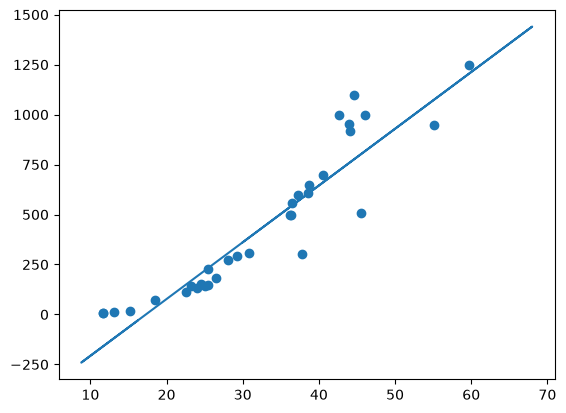

In [201]:
# TODO: scatter plot of test data with the fitted line drawn on top

plt.scatter(X_test,y_test)
plt.plot(X,linear_model.predict(X))

plt.show()



**Check your work:** R² should be about `0.86`, RMSE about `136` grams.

---
## Question 5: Curve It (Polynomial Regression)

Look closely at your plot from Question 4 — does the straight line fit equally well for small and large fish, or does it seem to systematically miss at one end? Weight isn't actually a straight-line function of length: for a fish that keeps roughly the same shape as it grows, weight scales more like *length cubed* than length. That's a curve, not a line.

**Your tasks:**
1. Transform `X_train` and `X_test` into polynomial features of degree 3 (this creates columns for x, x², and x³).
2. Fit a new linear regression model on the transformed training features — this is what "polynomial regression" actually is, a straight-line model fit on curved features.
3. Predict on the transformed test features, and compute R² and RMSE.
4. Compare: did R² go up and RMSE go down compared to your Question 4 model?
5. Plot the test data again, this time with your polynomial curve drawn on top (predict across a smooth, sorted range of x-values so the curve draws cleanly).

Hint: look up `PolynomialFeatures`.

In [ ]:
# TODO: transform X_train and X_test into degree-3 polynomial features

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)


# TODO: fit a linear regression model on the transformed features
poly_model = LinearRegression().fit(X_train_poly,y_train)

# TODO: predict on X_test_poly
poly_pred = poly_model.predict(X_test_poly)

# TODO: score with R2 and RMSE
poly_r2 = r2_score(poly_pred,y_test)
poly_rmse = (mean_squared_error(poly_pred,y_test))**0.5

print("Linear  -> R2:", linear_r2, " RMSE:", linear_rmse)
print("Poly(3) -> R2:", poly_r2, " RMSE:", poly_rmse)

<class 'pandas.DataFrame'>
Linear  -> R2: 0.8621909041179154  RMSE: 136.01319823866277
Poly(3) -> R2: 0.872465006522464  RMSE: 125.37152962855382


(32, 4)
(32,)
     Length3
129     37.8
46      25.0
135     45.5
157     15.2
91      24.0
29      42.6
97      25.5
99      26.5
96      25.5
141     59.7
19      38.7
57      30.8
15      37.2
70      28.0
24      40.5
30      44.1
123     44.6
110     36.5
94      24.5
66      23.2
151     13.1
18      38.6
12      36.4
9       36.2
31      44.0
82      22.5
52      29.2
140     55.1
126     46.0
147     11.6
146     11.6
76      18.5
[ 554.11650757  172.52419978  838.3747198    18.52654658  150.20962615
  728.73365166  184.17335276  208.42108095  184.17335276 1371.63774432
  585.98758378  325.9018202   533.13657349  247.06329853  651.02722912
  785.17595137  804.12618932  508.94872247  161.20067024  133.33265294
    6.76324978  582.42360448  505.51972354  498.6820809   781.39330352
  119.30002677  279.82921037 1204.59574478  857.46623596    3.61179725
    3.61179725   53.21471822]
(32, 1)
(32,)


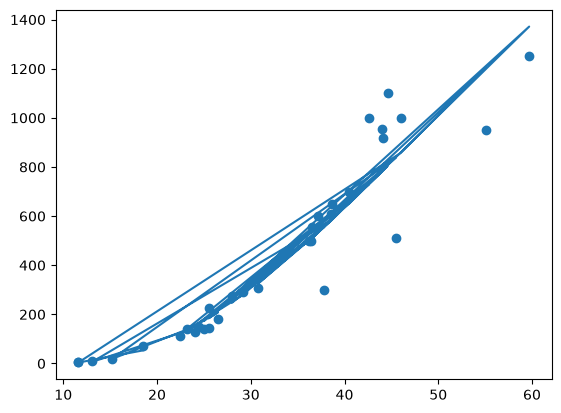

In [204]:
# TODO: scatter plot of test data with the polynomial curve drawn on top

plt.scatter(X_test,y_test)
print(X_test_poly.shape)
print(y_test.shape)
plt.plot(X_test,poly_model.predict(X_test_poly))
print(X_test)
print(poly_model.predict(X_test_poly))
print(X_test.shape)
print(poly_model.predict(X_test_poly).shape)
plt.show()


**Check your work:** The polynomial model's R² should be about `0.88`, RMSE about `125` grams — both better than the straight-line model.

---
## Question 6 (Capstone): Predict & Evaluate

Let's put your best model (the polynomial one) to work, and take an honest look at where it still makes mistakes.

**Your tasks:**
1. Using your polynomial model, predict the weight of four hypothetical fish with `Length3` measurements of 20, 30, 45, and 60 cm. Print each prediction.
2. Compute the **residuals** on the test set: `actual weight - predicted weight` for each fish. A good model's residuals should scatter randomly around 0, with no obvious pattern.
3. Make a residual plot: predicted weight on the x-axis, residual on the y-axis, with a horizontal reference line at 0.
4. Build a small DataFrame comparing your two models side by side, with columns `Model`, `R2`, and `RMSE` (rows: `"Linear"` and `"Polynomial (degree 3)"`).
5. In a markdown cell, write 2-3 sentences: which model would you actually recommend, and why? Is the improvement from polynomial regression big enough to matter?

Hint: for new/unseen `X` values, remember they need to go through the same `PolynomialFeatures` transform your training data did before you call `.predict()`. Look up `plt.axhline` for the reference line.

In [ ]:
# TODO: predict weight for Length3 = 20, 30, 45, 60 cm using the polynomial model
new_lengths = pd.DataFrame([20,30,45,60])
new_lengths = poly.fit_transform(new_lengths)
new_predictions = poly_model.predict(new_lengths)
print(new_predictions)



[  75.0741919   302.53655112  819.32748432 1382.14685502]


[ 242.   290.   340.   363.   430.   450.   500.   390.   450.   500.
  475.   500.   500.   340.   600.   600.   700.   700.   610.   650.
  575.   685.   620.   680.   700.   725.   720.   714.   850.  1000.
  920.   955.   925.   975.   950.    40.    69.    78.    87.   120.
  110.   120.   150.   145.   160.   140.   160.   169.   161.   200.
  180.   290.   272.   390.   270.   270.   306.   540.   800.  1000.
   55.    60.    90.   120.   150.   140.   170.   145.   200.   273.
  300.     5.9   32.    40.    51.5   70.   100.    78.    80.    85.
   85.   110.   115.   125.   130.   120.   120.   130.   135.   110.
  130.   150.   145.   150.   170.   225.   145.   188.   180.   197.
  218.   300.   260.   265.   250.   250.   300.   320.   514.   556.
  840.   685.   700.   700.   690.   900.   650.   820.   850.   900.
 1015.   820.  1100.  1000.  1100.  1000.  1000.   200.   300.   300.
  300.   430.   345.   456.   510.   540.   500.   567.   770.   950.
 1250.  1600.  1550.

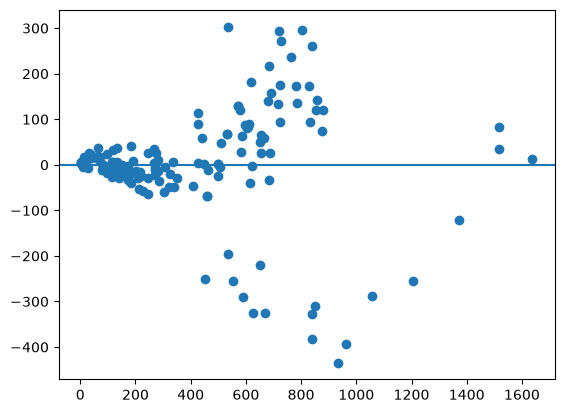

In [244]:
# TODO: residuals on the test set (actual - predicted, polynomial model)
weights = np.array(fish_clean["Weight"])
length3 = poly.fit_transform(pd.DataFrame(fish_clean["Length3"]))
length3_predictions = poly_model.predict(length3)
print(weights)
print(length3_predictions)

residuals = weights-length3_predictions
print(residuals)


# TODO: residual plot with a horizontal line at 0

plt.scatter(length3_predictions,residuals)
plt.axhline()
plt.show()


In [245]:
# TODO: build a comparison DataFrame with columns Model, R2, RMSE
model_comparison = pd.DataFrame({"Model":["Linear","Polynomial (degree 3)"],"R2":[linear_r2,poly_r2],"RMSE":[linear_rmse,poly_rmse]})

print(model_comparison)

                   Model        R2        RMSE
0                 Linear  0.862191  136.013198
1  Polynomial (degree 3)  0.872465  125.371530


**Your reflection (2-3 sentences):** Which model would you recommend, and why? Is the improvement from polynomial regression big enough to matter?

*I would recommend the polynomial model because a lower RMSE is more accurate. The RMSE is lower by ~11, which is around 8% of the linear RMSE. I think that 8% is a substiantial amount, especially when the more work needed by the polynomial model is only a couple lines of code. *

**Check your work:** Predicted weights for 20 / 30 / 45 / 60 cm should be about `75g`, `303g`, `819g`, `1382g`.

### Bonus (if you finish early)
- Try a different feature (e.g. `Height`, the weakest correlation) as your `best_feature` — does polynomial regression help more or less there?
- Try fitting a *separate* regression model per species instead of one for the whole dataset. Does that improve accuracy? (Hint: look up `DataFrame.groupby`.)
- Try polynomial degree 2 and degree 6 instead of 3. Is more always better? What happens to your test R² as the degree gets very high?